In [ ]:
import sys
import os

import numpy as np
import torch
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import gpytorch
from gpytorch.mlls import VariationalELBO

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define data and model

In [ ]:
TARGET = "H"

QUANTILES = torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95])
CENTER_QUANTILE_INDEX = 2
NUM_LOWER_QUANTILES = 2
NUM_LATENTS = 3
NUM_LOWER_LATENTS = 1

N_EPOCHS = 3127

In [ ]:
X = pd.read_csv("../_temp/X.csv")
y = pd.read_csv("../_temp/y.csv")[TARGET]

scaler = MinMaxScaler().fit(X.values)
X_scale = torch.tensor(scaler.scale_).float()
X_min = torch.tensor(scaler.min_).float()

X_scaled = torch.tensor(scaler.transform(X.values)).float()

In [ ]:
from scripts.model import MTGPQR_H
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

model = MTGPQR_H(
    inducing_points=X_scaled.clone(),
    num_quantiles=len(QUANTILES),
    num_lower_quantiles=NUM_LOWER_QUANTILES,
    num_latents=NUM_LATENTS,
    num_lower_latents=NUM_LOWER_LATENTS,
    X_scale=X_scale,
    X_min=X_min,
).to(device)
likelihood = MultitaskCenterGapQuantileGPLikelihood(
    QUANTILES, CENTER_QUANTILE_INDEX
).to(device)

# Train

In [ ]:
train_x = X_scaled.to(device)
train_y = torch.tensor(y.values).to(device)

model.train()
likelihood.train()

parameters = list(model.parameters()) + list(likelihood.parameters())
optimizer = torch.optim.Adam(
    parameters,
    lr=0.001,
)
mll = VariationalELBO(likelihood, model, num_data=len(train_y))

for i in range(N_EPOCHS):
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

# Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

model.eval()

data = pd.concat([X, y], axis=1)

groups = list(data.groupby(["Cos_theta"]))
Rgts = data["Gap_to_thickness_ratio"]
Rgt_pred = np.linspace(Rgts.min(), Rgts.max(), 100)
Cas = data["Capillary_number"]

## Plot prior mean

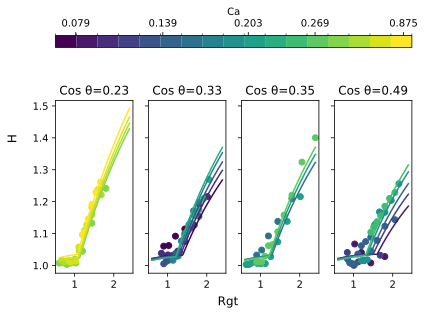

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

ca_unique = np.sort(Cas.unique())
n_colors = len(ca_unique)
cmap = plt.get_cmap("viridis", n_colors)
norm = mcolors.BoundaryNorm(
    np.concatenate(
        [
            [ca_unique[0] * 0.9],
            (ca_unique[:-1] + ca_unique[1:]) / 2,
            [ca_unique[-1] * 1.1],
        ]
    ),
    ncolors=n_colors,
)

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df[TARGET], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        X_pred_scaled = torch.tensor(scaler.transform(X_pred)).float().to(device)
        with torch.no_grad(), gpytorch.settings.prior_mode(state=True):
            prior_mean = model(X_pred_scaled).mean
        q_central = prior_mean[..., 0].cpu().numpy()
        ax.plot(
            Rgt_pred,
            q_central,
            color=color,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel(TARGET)

plt.show()

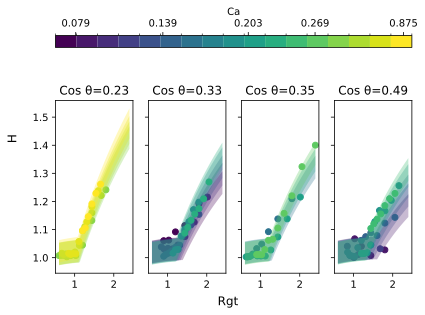

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

ca_unique = np.sort(Cas.unique())
n_colors = len(ca_unique)
cmap = plt.get_cmap("viridis", n_colors)
norm = mcolors.BoundaryNorm(
    np.concatenate(
        [
            [ca_unique[0] * 0.9],
            (ca_unique[:-1] + ca_unique[1:]) / 2,
            [ca_unique[-1] * 1.1],
        ]
    ),
    ncolors=n_colors,
)

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df[TARGET], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        X_pred_scaled = torch.tensor(scaler.transform(X_pred)).float().to(device)
        with torch.no_grad():
            quantiles = model.mean_quantiles_delta(X_pred_scaled)
        q_low, q_high = quantiles.T[[0, -1], ...].cpu().numpy()
        ax.fill_between(
            Rgt_pred,
            q_low,
            q_high,
            facecolor=color,
            edgecolor="none",
            alpha=0.3,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel(TARGET)

plt.show()